# 02 · Data Wrangling: Removing Duplicates

**Project:** Developer Technology Trends: Current Usage and Future Demand (IBM Data Analyst Professional Certificate, Capstone)

**Objective:** Find and remove duplicate survey responses, then handle missing values in two key columns.

**Data:** Stack Overflow Developer Survey, IBM Skills Network copy with injected duplicates (`survey-data-duplicates.csv`, 65,447 rows × 114 columns)

**Tools:** pandas (`duplicated`, `drop_duplicates`, `fillna`), Matplotlib

### Key results
- 10 duplicate rows removed: 65,447 → 65,437 responses.
- `EdLevel`: 4,653 missing values imputed with the mode, *Bachelor's degree*.
- `ConvertedCompYearly`: 42,002 missing values (64%) imputed with the median, $65,000.

> Based on an IBM Skills Network hands-on lab: the task instructions and setup cells come from the course, the solution code and the analysis are my own.

[← 01](01_data_collection_jobs_api.ipynb) · [Project README](../README.md) · [03 →](03_data_wrangling_finding_missing_values.ipynb)

## Introduction


In this lab, you will focus on data wrangling, an important step in preparing data for analysis. Data wrangling involves cleaning and organizing data to make it suitable for analysis. One key task in this process is removing duplicate entries, which are repeated entries that can distort analysis and lead to inaccurate conclusions.  


## Objectives


In this lab you will perform the following:


1. Identify duplicate rows  in the dataset.
2. Use suitable techniques to remove duplicate rows and verify the removal.
3. Summarize how to handle missing values appropriately.
4. Use ConvertedCompYearly to normalize compensation data.
   


### Install the Required Libraries


In [1]:
!pip install pandas

### Step 1: Import Required Libraries


In [2]:
import pandas as pd

### Step 2: Load the Dataset into a DataFrame



load the dataset using pd.read_csv()


In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

**Note: If you are working on a local Jupyter environment, you can use the URL directly in the <code>pandas.read_csv()</code>  function as shown below:**



In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Step 3: Identifying Duplicate Rows


**Task 1: Identify Duplicate Rows**
  1. Count the number of duplicate rows in the dataset.
  2. Display the first few duplicate rows to understand their structure.


**Approach:** `df.duplicated()` flags rows that are exact copies of an earlier row. The first duplicates repeat ResponseId 1–5.

In [4]:
dup_mask = df.duplicated()
num_dup = dup_mask.sum()
print(num_dup)

df[dup_mask].head()

10

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 4: Removing Duplicate Rows


**Task 2: Remove Duplicates**
   1. Remove duplicate rows from the dataset using the drop_duplicates() function.
2. Verify the removal by counting the number of duplicate rows after removal .


**Approach:** `drop_duplicates()` keeps the first occurrence of each row; re-counting confirms that no duplicates remain.

In [9]:
df_clean= df.drop_duplicates()
df_clean.duplicated().sum()

np.int64(0)

### Step 5: Handling Missing Values


**Task 3: Identify and Handle Missing Values**
   1. Identify missing values for all columns in the dataset.
   2. Choose a column with significant missing values (e.g., EdLevel) and impute with the most frequent value.


**Approach:** `EdLevel` is categorical, so its missing values are filled with the most frequent category (the mode).

In [16]:
df_clean.isna().sum().sort_values(ascending = False)
print(df_clean['EdLevel'].isna().sum())
most_freq = df_clean['EdLevel'].mode()[0]
print(most_freq)

df_clean['EdLevel'] = df_clean['EdLevel'].fillna(most_freq)
print(df_clean['EdLevel'].isna().sum())

4653
Bachelor’s degree (B.A., B.S., B.Eng., etc.)
0

### Step 6: Normalizing Compensation Data


**Task 4: Normalize Compensation Data Using ConvertedCompYearly**
   1. Use the ConvertedCompYearly column for compensation analysis as the normalized annual compensation is already provided.
   2. Check for missing values in ConvertedCompYearly and handle them if necessary.


**Approach:** `ConvertedCompYearly` is already converted to USD. Missing values are filled with the median, which is robust to the extreme salaries in this column.

In [17]:
print(df_clean['ConvertedCompYearly'].describe())

num_nan = df_clean['ConvertedCompYearly'].isna().sum()
print(num_nan)
print(num_nan / len(df_clean) * 100)

median_comp = df_clean['ConvertedCompYearly'].median()
df_clean['ConvertedCompYearly'] = df_clean['ConvertedCompYearly'].fillna(median_comp)

print(df_clean['ConvertedCompYearly'].isna().sum())

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64
42002
64.1869278848358
0

### Step 7: Summary and Next Steps


**In this lab, you focused on identifying and removing duplicate rows.**

- You handled missing values by imputing the most frequent value in a chosen column.

- You used ConvertedCompYearly for compensation normalization and handled missing values.

- For further analysis, consider exploring other columns or visualizing the cleaned dataset.


### Cleaning summary
Shape before and after cleaning, plus two quick checks: education levels after imputation and the compensation distribution (values above the 99th percentile hidden for readability).

Before: (65447, 114)
After: (65437, 114)
Rows removed: 10
EdLevel                0
ConvertedCompYearly    0
dtype: int64

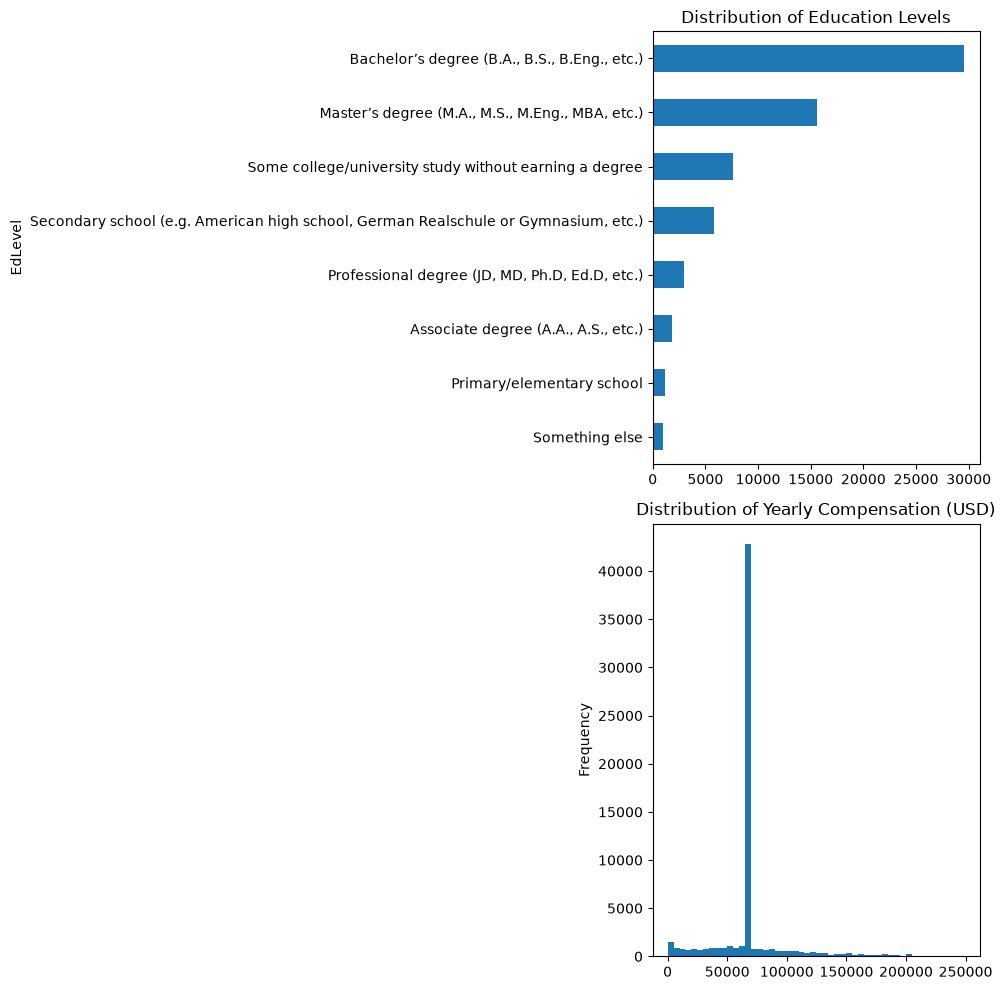

In [18]:
import matplotlib.pyplot as plt

# Cleaning summary
print("Before:", df.shape)
print("After:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])
print(df_clean[['EdLevel', 'ConvertedCompYearly']].isna().sum())

# Data for the charts
edu_counts = df_clean['EdLevel'].value_counts()
comp = df_clean['ConvertedCompYearly']
limit = comp.quantile(0.99)

# Two charts in the same cell
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
edu_counts.plot(kind='barh', ax=axes[0])
axes[0].set_title('Distribution of Education Levels')
axes[0].invert_yaxis()
comp[comp < limit].plot(kind='hist', bins=50, ax=axes[1])
axes[1].set_title('Distribution of Yearly Compensation (USD)')
plt.tight_layout()
plt.show()

<!--
## Change Log

|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|

--!>


Copyright © IBM Corporation. All rights reserved.
